In [45]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

from config import Config
import data

In [2]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/global_mutligraph/proto_era5_q_20251006_212819")

In [3]:
results = pd.read_parquet(run_dir / 'results' / 'test_results.parquet')
results

Type                                            obs       pred
Feature                                   discharge  discharge
basin          subbasin       date                            
USGS-10396000  USGS-10396000  2020-05-09   6.852678   1.026570
USGS-11425500  77001576       2022-11-26        NaN   1.717927
               77001619       2022-11-26        NaN   3.603536
               77001644       2022-11-26        NaN   0.228812
               77001825       2022-11-26        NaN  34.099754
...                                             ...        ...
ABOM-79077010  ABOM-79077010  2020-10-24   0.086000   0.292159
USGS-10396000  USGS-10396000  2022-12-07   0.693763   0.173057
USGS-12048000  USGS-12048000  2022-10-10   2.358793   5.462908
ABOM-142635010 ABOM-142635010 2020-10-14   0.918000   2.822336
ECCC-02YG001   ECCC-02YG001   2024-04-29  45.403477  21.051027

[8730990 rows x 2 columns]

In [6]:
import geopandas as gpd

data_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph")
matchups = gpd.read_parquet(data_dir / "metadata" / "All_MERIT_matchups.parquet").set_index('comid')
matchups.index = matchups.index.astype(str)
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,-112.230256,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154..."
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,-66.459568,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ..."
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,-66.496560,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ..."


In [52]:
outlets = matchups[matchups.index == matchups['outlet_id']]

In [34]:
train_basins = pd.read_csv(data_dir / 'basin_lists' / 'train_8020.txt', header=None)[0].to_list()
matchups['train'] = False
matchups.loc[train_basins, 'train'] = True
matchups


,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry,train
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9...",False
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0...",False
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5...",False
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6...",False
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154...",True
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ...",False
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ...",False


In [65]:
list(outlets)


['outlet',
 'outlet_id',
 'total_area',
 'unitarea',
 'reservoir',
 'custom',
 'reach_id',
 'sword_area',
 'sword_distance',
 'lake_reach_ids',
 'lake_pld_ids',
 's2m_values',
 'name',
 'area',
 'latitude',
 'longitude',
 'min_date',
 'max_date',
 'min_discharge',
 'max_discharge',
 'mean_discharge',
 'count_discharge',
 'provider',
 'hybas_area_diff',
 'geometry',
 'train']

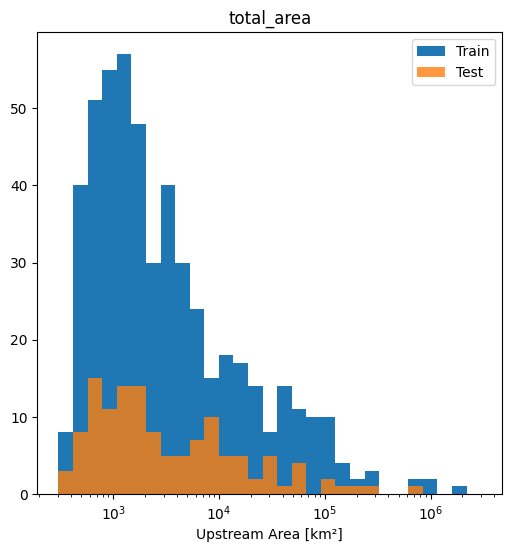

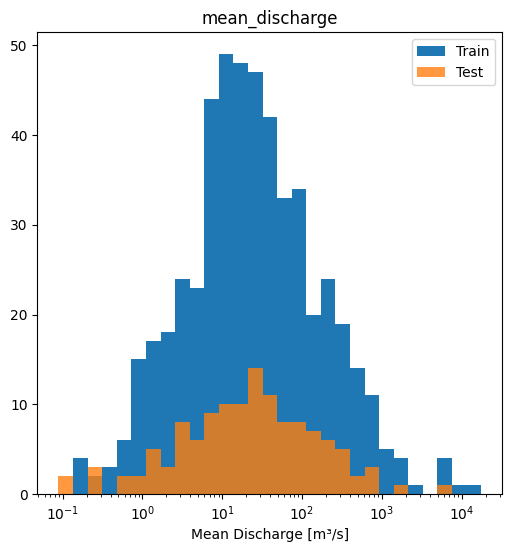

In [64]:
def train_test_hist(train, test, col, kwgs):
    fig, ax = plt.subplots(1, figsize=(6,6))
    data = outlets[col]
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)
    
    ax.hist(train[col], bins=bins, label='Train')
    ax.hist(test[col], bins=bins, alpha=0.8, label='Test')
    ax.set_title(col)
    ax.set_xlabel(kwgs.get('xlabel',''))
    plt.xscale('log')
    plt.legend()
    fig.show()

train_basins = outlets[outlets['train']]
test_basins = outlets[~outlets['train']]

plot_cfg = {
    'total_area': {'xlabel':'Upstream Area [km²]'}, 
    'mean_discharge': {'xlabel':'Mean Discharge [m³/s]'}
}
for col, kwgs in plot_cfg.items():
    train_test_hist(train_basins, test_basins, col, kwgs)

In [50]:
test_matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry,train
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9...",False
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0...",False
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5...",False
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6...",False
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-394220106431500,POINT (-106.7683 39.6775),USGS-09522000,1844.1,340.5,False,True,7.728080e+10,2110.051796,0.0,[],...,2006-04-29,2025-09-08,1.081704,161.972363,13.388783,7072.0,usgs,-0.054879,"MULTIPOLYGON (((-106.70125 39.62958, -106.7012...",False
USGS-402114105350101,POINT (-105.6525 40.35),USGS-07374525,88.2,88.2,False,True,NaN,NaN,NaN,[],...,1995-10-01,2025-09-08,0.015008,21.549120,1.550812,9640.0,usgs,0.149974,"MULTIPOLYGON (((-105.77875 40.43375, -105.7737...",False
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ...",False


In [ ]:
from shapely.ops import unary_union
basin_geoms = {
    basin: {'geometry': unary_union(row.geometry.envelope)}
    for basin, row in matchups.groupby('outlet_id')
}
basin_geoms

In [15]:
basin_gdf

,geometry
ABOM-100288010,"POLYGON ((116.44292 -33.16208, 115.97292 -33.1..."
ABOM-107434010,"POLYGON ((116.50375 -32.21125, 116.50375 -32.5..."
ABOM-108118010,"POLYGON ((116.56958 -32.17375, 116.56958 -31.9..."
ABOM-113129010,"POLYGON ((115.87875 -30.87042, 115.87875 -30.9..."
ABOM-113192010,"POLYGON ((115.21125 -30.15292, 115.21125 -29.8..."
...,...
USGS-15908000,"POLYGON ((-149.85958 68.53708, -149.22458 68.5..."
USGS-255432081303900,"POLYGON ((-81.33292 26.31125, -81.33292 25.902..."
USGS-410401112134801,"POLYGON ((-112.08875 39.76708, -112.08875 39.8..."
USGS-50037000,"POLYGON ((-66.27792 18.33125, -66.27792 18.147..."


In [ ]:
basin_gdf = gpd.GeoDataFrame(basin_geoms).T
basin_gdf.set_geometry('geometry', inplace=True)
basin_gdf.set_crs('EPSG:4326',  inplace=True)
basin_gdf.to_crs('ESRI:53030',  inplace=True)

In [32]:
basin_gdf['train'] = False
basin_gdf.loc[train_basins, 'train'] = True
basin_gdf

,geometry,train
ABOM-100288010,"POLYGON ((10433961.848 -3542858.953, 10391847....",True
ABOM-107434010,"POLYGON ((10475989.136 -3441267.934, 10464264....",True
ABOM-108118010,"POLYGON ((10483320.553 -3437260.841, 10491242....",False
ABOM-113129010,"POLYGON ((10468410.452 -3297982.292, 10467329....",False
ABOM-113192010,"POLYGON ((10432616.261 -3221307.742, 10443691....",True
...,...,...
USGS-15908000,"POLYGON ((-10336861.567 7135651.719, -10293061...",True
USGS-255432081303900,"POLYGON ((-7445424.119 2810878.483, -7452800.0...",True
USGS-410401112134801,"POLYGON ((-9760096.765 4246837.838, -9756213.3...",True
USGS-50037000,"POLYGON ((-6160679.8 1958365.769, -6162542.465...",False


<Axes: >

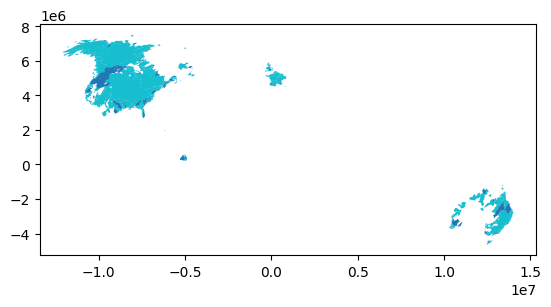

In [37]:
basin_gdf.plot('train')

In [24]:
basin_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
import evaluate
basin_m = evaluate.get_basin_metrics(results)

In [47]:
import geopandas as gpd
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/reservoirs")
metadata_dir = save_dir / "metadata"
matchups = gpd.read_parquet(metadata_dir / "All_MERIT_matchups.parquet").set_index('comid')
matchups.index = matchups.index.astype(str)

In [50]:
list(matchups.dropna(subset='mean_discharge'))

['outlet',
 'outlet_id',
 'total_area',
 'unitarea',
 'reservoir',
 'custom',
 'reach_id',
 'sword_area',
 'sword_distance',
 'lake_reach_ids',
 'lake_pld_ids',
 's2m_values',
 'name',
 'area',
 'latitude',
 'longitude',
 'min_date',
 'max_date',
 'min_discharge',
 'max_discharge',
 'mean_discharge',
 'count_discharge',
 'provider',
 'hybas_area_diff',
 'geometry']

In [53]:
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,-112.230256,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154..."
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,-66.459568,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ..."
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,-66.496560,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ..."


In [37]:
outlets = matchups.copy()
outlets.geometry = gpd.GeoSeries.from_wkt(outlets['outlet']).set_crs('EPSG:4326')

outlet_metrics = outlets.join(basin_m['discharge'], how='inner')

<Axes: >

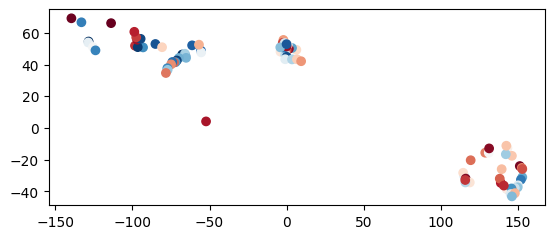

In [38]:
outlet_metrics.plot('NSE', cmap='RdBu')

In [9]:
results

NameError: name 'results' is not defined

<Axes: >

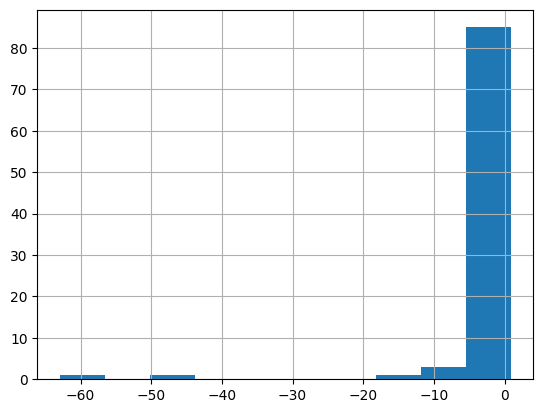

In [44]:
outlet_metrics['NSE'].hist()

In [7]:
with open(run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 1195581,
  'R2': 0.2531314492225647,
  'MAPE': 6111.718368530273,
  'nBias': -1.0169042274355888,
  'RE': 163.2274627685547,
  'RB': -1.0273456573486328,
  'qRE': array([ 57.17298673, 163.22744205, 483.46182911]),
  'qnBias': array([-58.69973451,  -1.01690427, 194.47716177]),
  'MAE': 29.515337,
  'RMSE': 134.3624,
  'rRMSE': 448.8661766052246,
  'KGE': 0.45888651654987755,
  'NSE': 0.2531315352714443,
  'Agreement': 0.509123471526809}}

In [8]:
basin_m['discharge'][['NSE','R2']]

Metric,NSE,R2
ABOM-113192010,0.311099,0.311099
ABOM-117649010,0.137957,0.137957
ABOM-122989010,-0.029531,-0.029531
ABOM-128547010,0.004116,0.004116
ABOM-134767010,0.473615,0.473615
...,...,...
USGS-01371500,0.567267,0.567267
USGS-01465500,0.031238,0.031238
USGS-01673000,0.54105,0.541049
USGS-02047000,0.423409,0.423409


In [92]:
import evaluate

def get_metrics(grp):
   return evaluate.metrics.calc_nse(grp['obs']['discharge'], grp['pred']['discharge'])
df = results.dropna().groupby('subbasin').apply(get_metrics)


<Axes: >

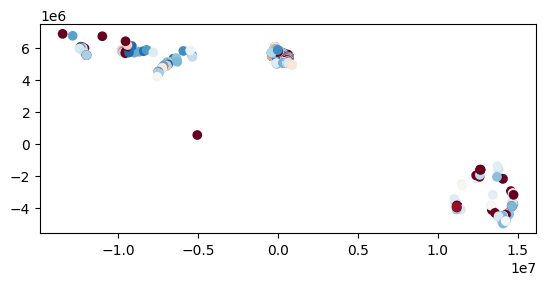

In [99]:
outlet_nse = outlets.join(df.rename('NSE'), how='inner').to_crs("EPSG:6933")

outlet_nse.plot('NSE', vmin=-1, vmax=1, cmap='RdBu')

In [64]:
evaluate.get_all_metrics(grp[1])['discharge']['NSE']

0.1983168125152588

In [51]:
results.dropna()

Type                                           obs      pred
Feature                                  discharge discharge
basin          subbasin       date                          
EAUF-V7200010  EAUF-U0020010  2024-09-18  0.802000  0.044893
               EAUF-U0045004  2024-09-18  0.113000  3.230401
               EAUF-U0104010  2024-09-18  0.715000  4.977508
               EAUF-U0124010  2024-09-18  3.076000  0.972183
               EAUF-U0204001  2024-09-18  0.120000  2.277400
...                                            ...       ...
ABOM-82216010  ABOM-82216010  2022-10-29  0.665000  0.020420
ABOM-280790010 ABOM-280790010 2024-03-26  0.195000  0.045741
EAUF-G0170420  EAUF-G0170420  2022-07-18  4.135000  1.835687
ABOM-189366010 ABOM-189366010 2022-06-23  1.512000  8.235313
EAUF-G0170420  EAUF-G0170420  2023-02-14  5.821001  5.109054

[1195581 rows x 2 columns]

In [19]:
results

Type                                           obs       pred
Feature                                  discharge  discharge
basin          subbasin       date                           
EAUF-V7200010  21000001       2024-09-18       NaN   2.571632
               21000012       2024-09-18       NaN   0.122315
               21000019       2024-09-18       NaN  20.593681
               21000021       2024-09-18       NaN  25.678551
               21000022       2024-09-18       NaN  11.528290
...                                            ...        ...
ABOM-82216010  ABOM-82216010  2022-10-29  0.665000   0.020420
ABOM-280790010 ABOM-280790010 2024-03-26  0.195000   0.045741
EAUF-G0170420  EAUF-G0170420  2022-07-18  4.135000   1.835687
ABOM-189366010 ABOM-189366010 2022-06-23  1.512000   8.235313
EAUF-G0170420  EAUF-G0170420  2023-02-14  5.821001   5.109054

[3467184 rows x 2 columns]

<Axes: xlabel='basin,date'>

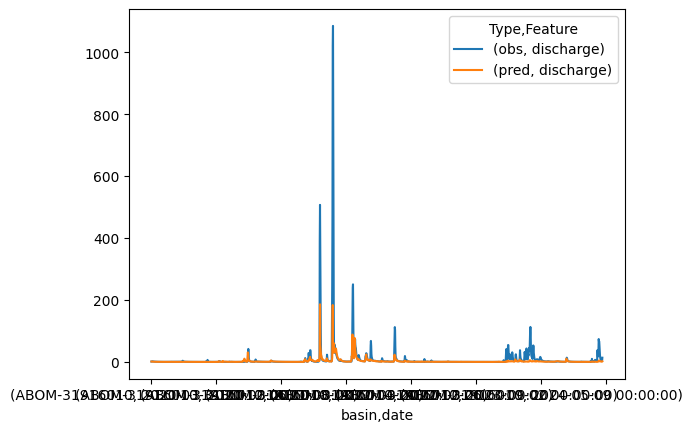

In [25]:
basin = 'ABOM-31916010'

df = results.xs(basin, level='subbasin')
df.sort_index().plot()

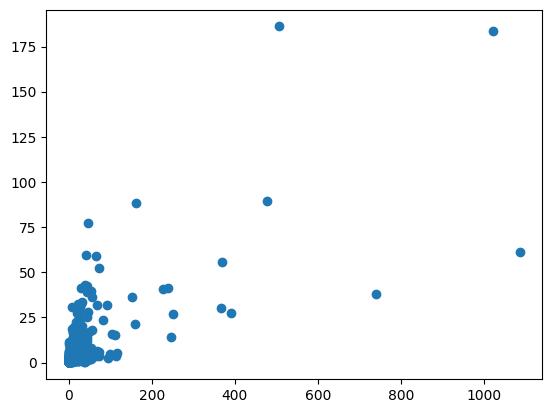

In [30]:
plt.scatter(df['obs']['discharge'], df['pred']['discharge'])

In [24]:
import pickle
with open(results_dir / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 108385,
  'R2': -0.02997457981109619,
  'MAPE': 427.0320415496826,
  'nBias': -0.05712399142794311,
  'RE': 232.67614841461182,
  'RB': -0.05716085433959961,
  'qRE': array([ 73.60065994, 232.67614947, 654.88286463]),
  'qnBias': array([-6.98563695e+01, -5.71239914e-02,  2.33670533e+02]),
  'MAE': 53.644592,
  'RMSE': 194.12527,
  'rRMSE': 1688.498306274414,
  'KGE': -0.3831915309608416,
  'NSE': -0.02997457981109619,
  'Agreement': 0.029437440800148096}}

In [35]:
targets = list(bulk_m.keys())

In [ ]:
import geopandas as gpd
proj_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/distributed")
metadata_dir = proj_dir / "metadata"
basins = gpd.read_file(metadata_dir / 'matchups.geojson').set_index("HYBAS_ID")
basins.index = basins.index.astype(str)
basins

In [ ]:
import evaluate
pred = evaluate.predict(trainer.model, dataloader, denormalize=False)

In [ ]:
pred

In [ ]:
x = pred.xs('2021-02-08', level='date')


x['pred']['discharge']

In [ ]:
x['pred']['discharge'].hist()

In [ ]:
basins_pred = basins.merge(x['pred']['discharge'], left_index=True, right_index=True)
basins_pred.plot('discharge')

In [ ]:
plt.scatter(x['obs']['discharge'], x['pred']['discharge'])
# plt.plot([0,500], [0,500], 'r--')